# **Практическая работа №10. Генерация сигналов и преобразования Фурье**

# Блок №1. Базовый уровень

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq,fftshift
from scipy.signal import spectrogram

## **Задание 1: Генерация сигналов**



В этом задании вам нужно создать различные виды сигналов. Сигналы являются основой цифровой обработки сигналов, и умение их генерировать является важным навыком.













1. **Синусоидальный сигнал**: Синусоидальный сигнал можно представить как $A \sin(2\pi ft + \phi)$, где $A$ - амплитуда, $f$ - частота, $\phi$ - фаза.

- Создайте функцию, которая принимает эти параметры, а также длительность сигнала, и возвращает сгенерированный сигнал.

### Пример:



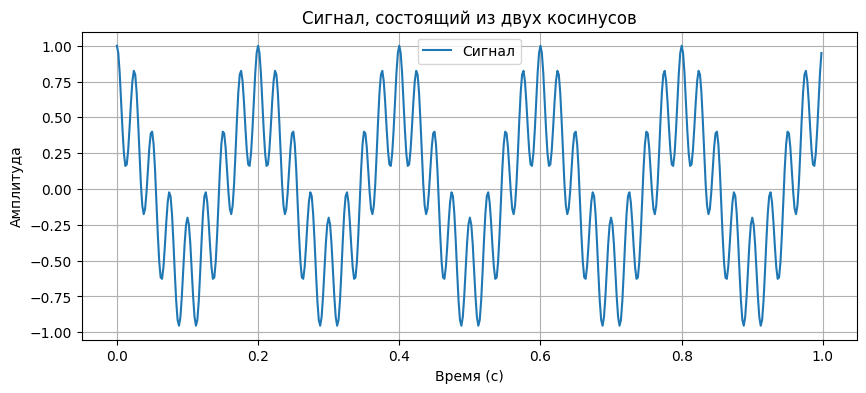

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Параметры времени
T = 1.0         # длительность сигнала в секундах
fs = 500.0      # частота дискретизации (в герцах)
t = np.arange(0, T, 1/fs) # массив времени

# Создание сигнала
f1 = 5.0        # частота первого косинуса
f2 = 40.0       # частота второго косинуса
a1 = 0.6        # амплитуда первого косинуса
a2 = 0.4        # амплитуда второго косинуса
signal = a1*np.cos(2*np.pi*f1*t) + a2*np.cos(2*np.pi*f2*t)

# Визуализация сигнала
plt.figure(figsize=(10, 4))
plt.plot(t, signal, label='Сигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Cигнал, состоящий из двух косинусов')
plt.legend()
plt.grid(True)
plt.show()


### Ваш код:

/tmp/ipykernel_3490/2020483577.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


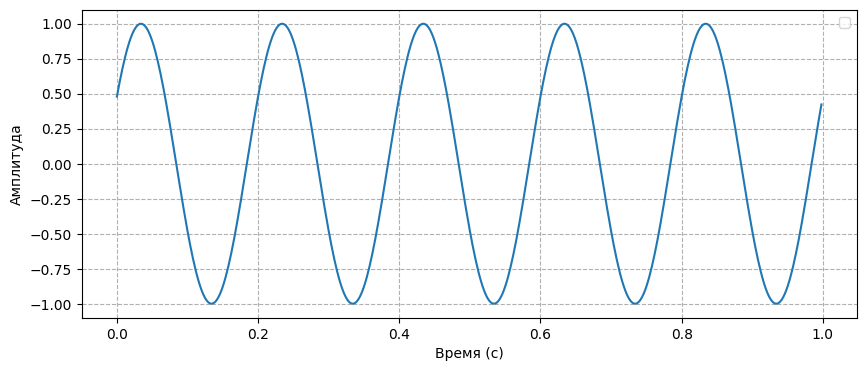

In [4]:
def gen_sig(A, f, fi, t_):
  return A * np.sin(2 * np.pi * f * t_ + fi)

T = 1.0
fs = 500.0
t = np.arange(0, T, 1/fs)
signal = gen_sig(1.0, 5.0, 0.5, t)

plt.figure(figsize=(10, 4))
plt.plot(t, signal)
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

2. **Сумма синусоид**: Сигнал, состоящий из суммы двух синусоид, можно представить как $A_1 \sin(2\pi f_1t + \phi_1) + A_2 \sin(2\pi f_2t + \phi_2)$.

- Создайте функцию, которая принимает параметры для двух синусоид, а также длительность сигнала, и возвращает сгенерированный сигнал.

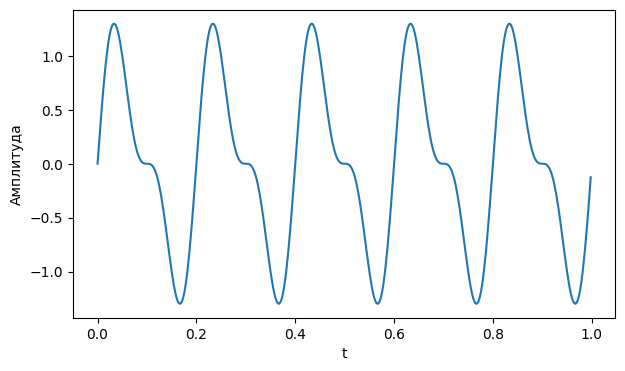

In [5]:
def generate_sum_sinus(a1, f1, phi1, a2, f2, phi2, T, fs):
    t = np.arange(0, T, 1/fs)
    signal = a1 * np.sin(2 * np.pi * f1 * t + phi1) + a2 * np.sin(2 * np.pi * f2 * t + phi2)
    return t, signal
t_sum, signal_sum = generate_sum_sinus(1.0, 5.0, 0, 0.5, 10.0, 0, T, fs)
plt.figure(figsize=(7, 4))
plt.plot(t_sum, signal_sum)
plt.xlabel('t')
plt.ylabel('Амплитуда')
plt.show()


3. **Шумовой сигнал**: Шумовой сигнал (или белый шум) можно сгенерировать как случайные значения из нормального распределения.

- Создайте функцию, которая принимает амплитуду шума и длительность сигнала, и возвращает сгенерированный шумовой сигнал.

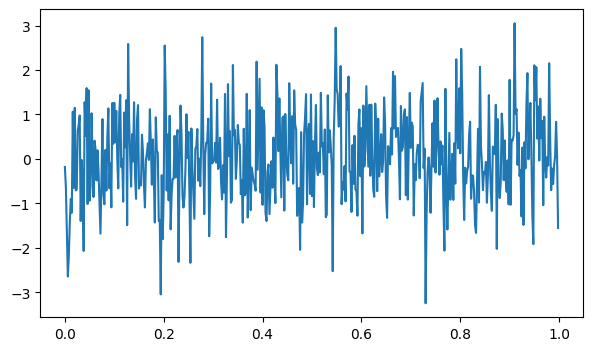

In [6]:
def generate_shum(noise_amplitude, T, fs):
    t = np.arange(0, T, 1/fs)
    noise = noise_amplitude * np.random.randn(len(t))
    return t, noise
t_noise, noise_signal = generate_shum(1.0, T, fs)
plt.figure(figsize=(7, 4))
plt.plot(t_noise, noise_signal)
plt.show()

4. **Синусоида плюс шум**: Сигнал, который представляет собой сумму синусоиды и шума, можно сгенерировать путем сложения синусоидального и шумового сигналов.
- Создайте функцию, которая принимает параметры для синусоиды и шума, а также длительность сигнала, и возвращает сгенерированный сигнал.

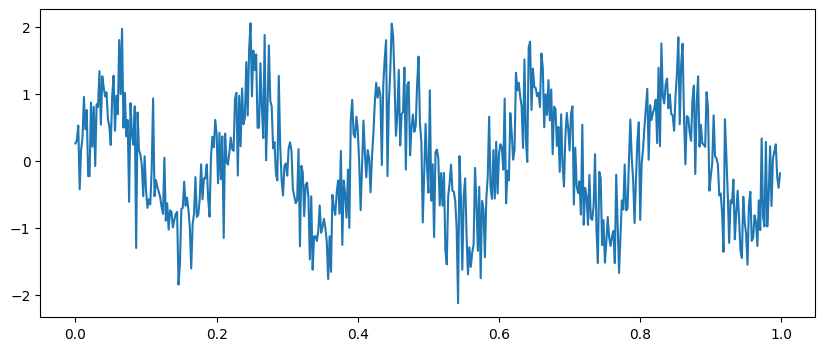

In [7]:
def generate_sinus_and_shum(a, f, phi, noise_amplitude, T, fs):
    t = np.arange(0, T, 1/fs)
    sinusoid = a * np.sin(2 * np.pi * f * t + phi)
    noise = noise_amplitude * np.random.randn(len(t))
    signal_and_shum = sinusoid + noise
    return t, signal_and_shum
t_res, final_signal = generate_sinus_and_shum(1.0, 5.0, 0, 0.5, T, fs)
plt.figure(figsize=(10, 4))
plt.plot(t_res, final_signal)
plt.show()


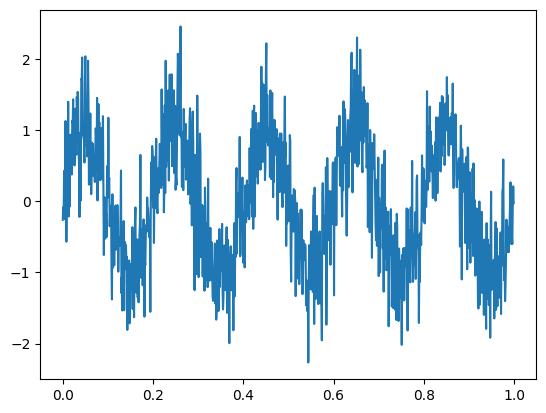

In [ ]:
# Пример

## **Задание 2: Преобразование Фурье**


Преобразование Фурье позволяет перейти от временного представления сигнала к частотному. Это основной инструмент для анализа сигналов. Создайте функцию, которая принимает сигнал и возвращает его преобразование Фурье.


1. Примените преобразование Фурье к синусоидальному сигналу и визуализируйте результат.


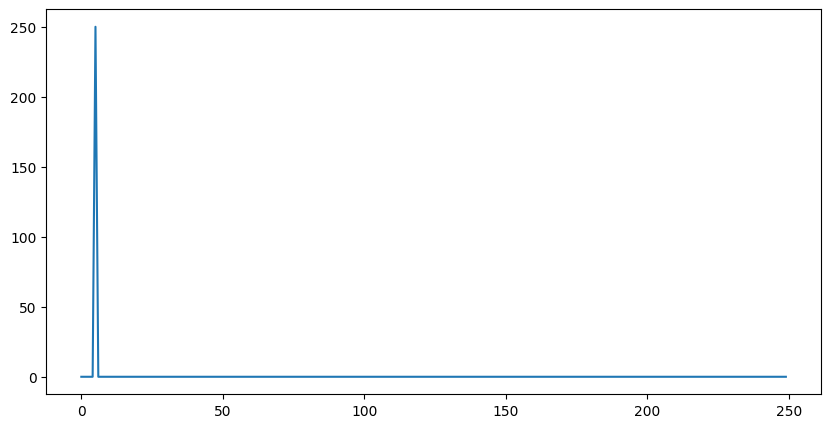

In [8]:
def get_fur(signal):
    n = len(signal)
    xf = fftfreq(n, 1/fs)
    yf = fft(signal)
    return xf, np.abs(yf)
xf, yf = get_fur(signal)
n = len(signal)
plt.figure(figsize=(10, 5))
plt.plot(xf[:n//2], yf[:n//2])
plt.show()


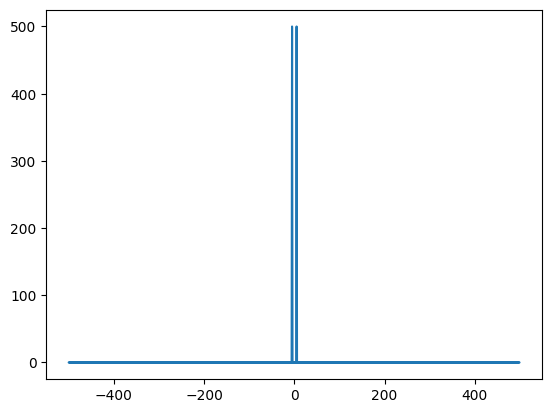

In [ ]:
# Пример

2. Примените преобразование Фурье к сигналу, состоящему из суммы двух синусоид, и визуализируйте результат.


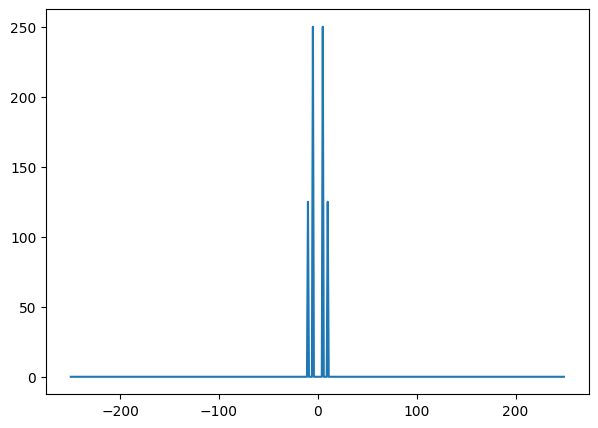

In [9]:
def get_fur_sum_2_sin(signal, fs):
    n = len(signal)
    yf = fft(signal)
    xf = fftfreq(n, 1/fs)
    return fftshift(xf), fftshift(np.abs(yf))
xf, yf = get_fur_sum_2_sin(signal_sum, fs)
plt.figure(figsize=(7, 5))
plt.plot(xf, yf)
plt.show()


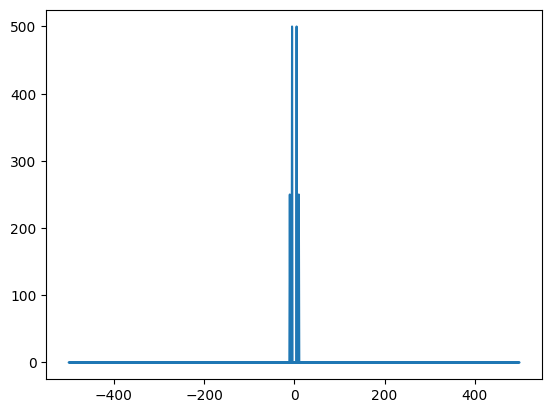

In [ ]:
# Пример

3. Примените преобразование Фурье к шумовому сигналу и визуализируйте результат.


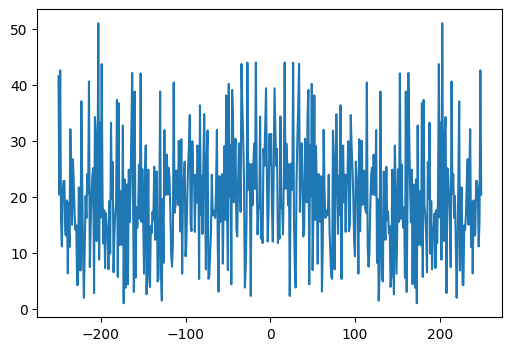

In [10]:
def get_fur_shum(signal, fs):
    n = len(signal)
    yf = fft(signal)
    xf = fftfreq(n, 1/fs)
    idx = np.argsort(xf)
    return xf[idx], np.abs(yf[idx])
xf_noise, yf_noise = get_fur_shum(noise_signal, fs)
plt.figure(figsize=(6, 4))
plt.plot(xf_noise, yf_noise)
plt.show()


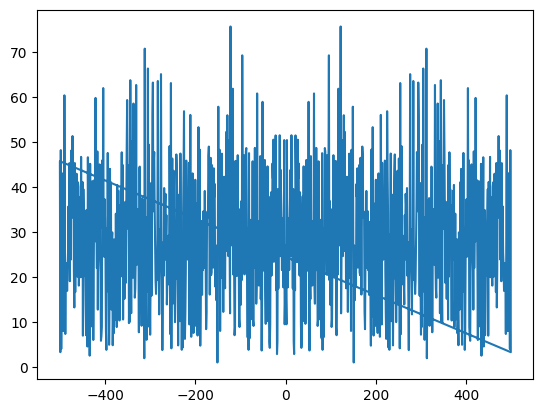

In [ ]:
# Пример

4. Примените преобразование Фурье к сигналу, который представляет собой сумму синусоиды и шума, и визуализируйте результат.

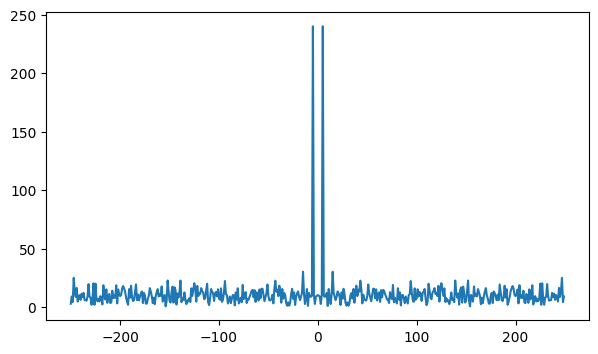

In [11]:
def get_noisy_sinusoid(signal, fs):
    n = len(signal)
    yf = fft(signal)
    xf = fftfreq(n, 1/fs)
    return fftshift(xf), fftshift(np.abs(yf))
xf_final, yf_final = get_noisy_sinusoid(final_signal, fs)
plt.figure(figsize=(7, 4))
plt.plot(xf_final, yf_final)
plt.show()

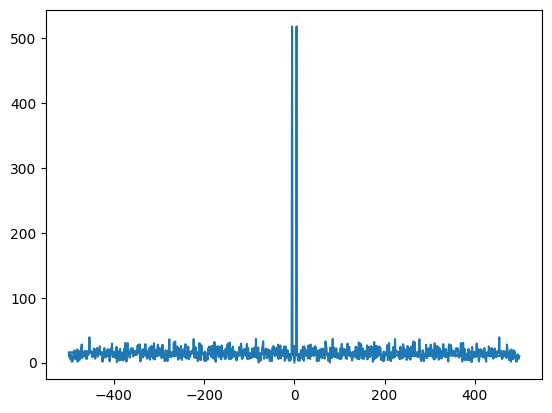

In [ ]:
# Пример

## **Задание 3: Фильтрация сигналов**

Фильтрация сигналов позволяет улучшить качество сигнала, убрав нежелательные частоты. Создайте функцию, которая принимает сигнал и частоту среза, и возвращает отфильтрованный сигнал.




1. Создайте функцию для фильтрации сигнала с использованием преобразования Фурье.

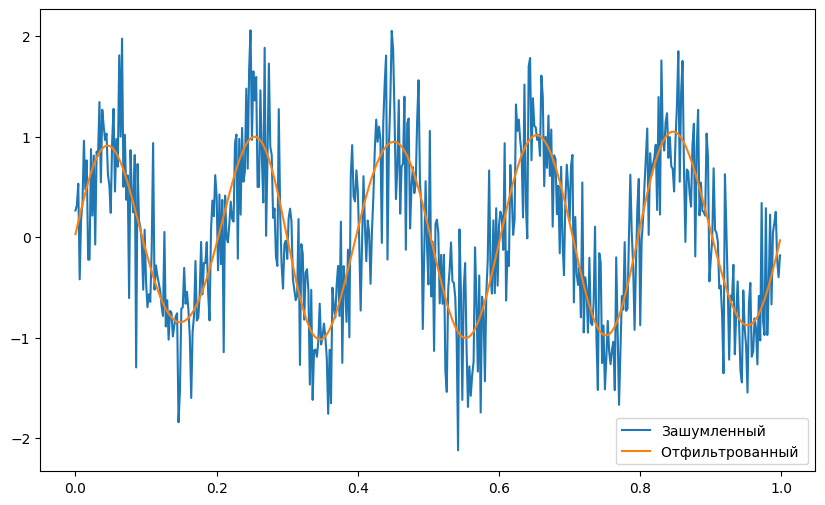

In [12]:
def filter(signal, cutoff_freq, fs):
    n = len(signal)
    yf = fft(signal)
    xf = fftfreq(n, 1/fs)
    yf_filtered = yf.copy()
    yf_filtered[np.abs(xf) > cutoff_freq] = 0
    filtered_signal = np.real(ifft(yf_filtered))
    return filtered_signal
cutoff = 10.0
filtered_res = filter(final_signal, cutoff, fs)
plt.figure(figsize=(10, 6))
plt.plot(t, final_signal, label='Зашумленный')
plt.plot(t, filtered_res, label='Отфильтрованный ')
plt.legend()
plt.show()


2. Примените эту функцию к сигналу, который представляет собой сумму синусоиды и шума, и визуализируйте результаты до и после фильтрации.

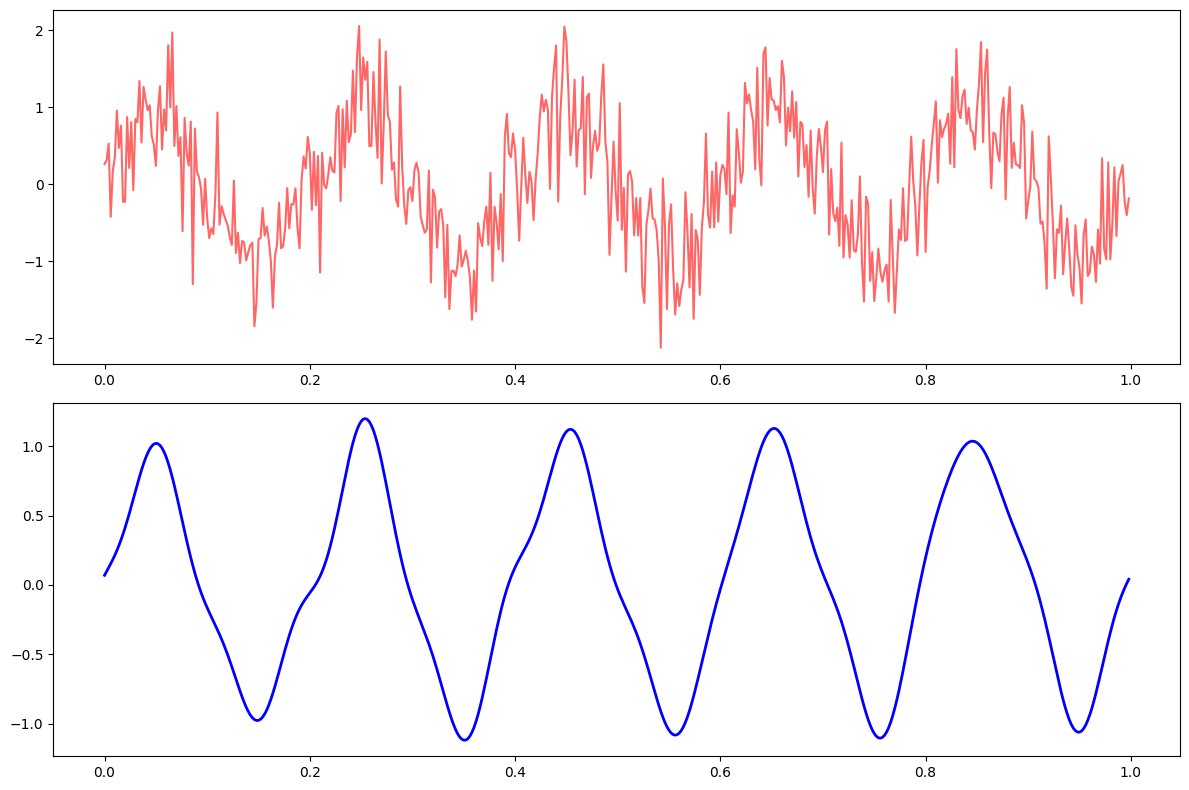

In [13]:
cutoff = 15
filtered_signal = filter(final_signal, cutoff, fs)
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(t, final_signal, color='red', alpha=0.6)
plt.subplot(2, 1, 2)
plt.plot(t, filtered_signal, color='blue', linewidth=2)
plt.tight_layout()
plt.show()


## **Задание 4: Анализ сигналов**

Анализ сигналов включает в себя различные методы и техники для изучения и понимания сигналов. Создайте функцию, которая принимает сигнал и возвращает его спектрограмму (**scipy.signal.spectrogram**).


**Спектрограмма** - это визуальное представление спектра частот сигнала во времени. Она показывает, какие частоты присутствуют в сигнале в каждый момент времени. Вот как правильно понимать спектрограмму:

- **Ось X**: Это время. Она показывает продолжительность сигнала. Каждый столбец на спектрограмме представляет собой отдельный момент времени.

- **Ось Y**: Это частота. Она показывает различные частоты, которые присутствуют в сигнале. Каждая строка на спектрограмме представляет собой отдельную частоту.

- **Значение**: Значение в каждой точке (x, y) показывает амплитуду (или интенсивность) данной частоты в данное время. Обычно более яркие цвета означают большую амплитуду, а более темные цвета - меньшую амплитуду.

Таким образом, спектрограмма позволяет вам видеть, как меняется спектральный состав сигнала во времени. Это может быть полезно во многих областях, включая анализ речи, музыку, радиосигналы и многое другое. Например, в анализе речи вы можете видеть, как меняются форманты (основные частоты) во время произношения различных звуков. В музыке вы можете видеть, как меняются ноты во время проигрывания песни.

1. Создайте функцию для вычисления и визуализации спектрограммы сигнала.


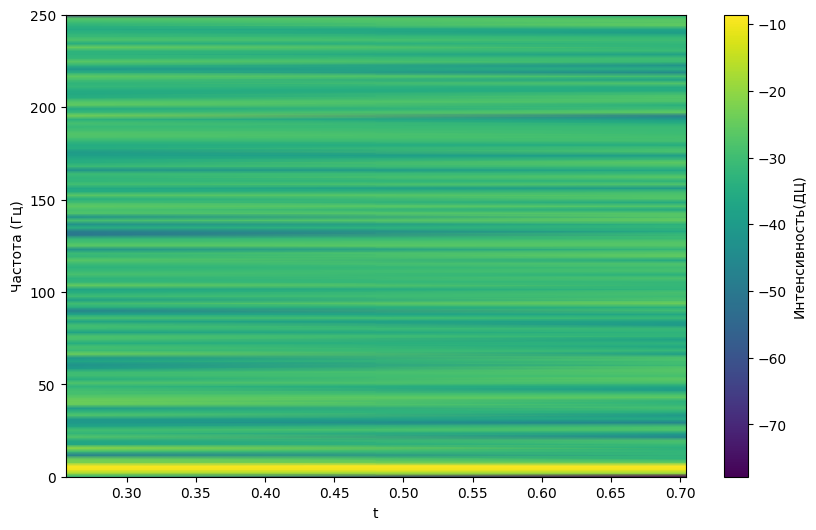

In [14]:
from scipy.signal import spectrogram
def spectrogramma(signal, fs):
    f, t_spec, Sxx = spectrogram(signal, fs)
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx), shading='gouraud', cmap='viridis')
    plt.ylabel('Частота (Гц)')
    plt.xlabel('t')
    plt.colorbar(label='Интенсивность(ДЦ)')
    plt.ylim(0, fs/2)
    plt.show()
spectrogramma(final_signal, fs)


2. Примените эту функцию к различным сигналам, которые вы сгенерировали и проанализировали в предыдущих заданиях.

Анализ чистого сигнала:


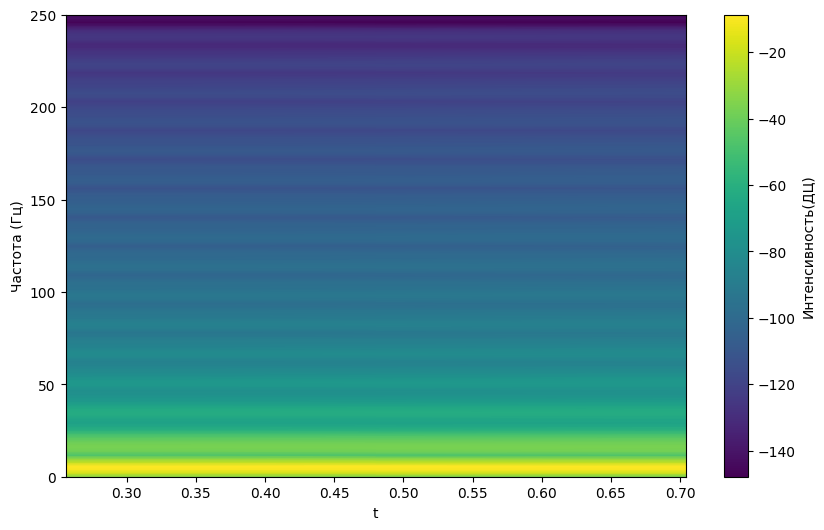

Анализ белого шума:


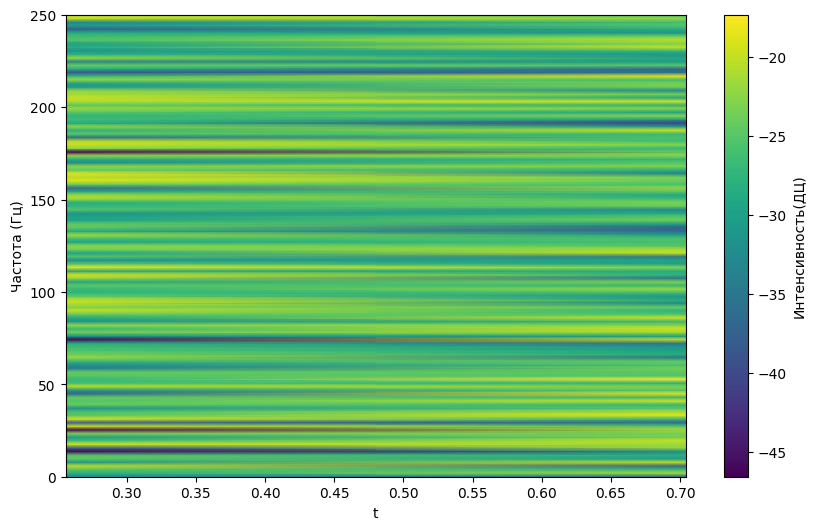

Анализ отфильтрованного сигнала:


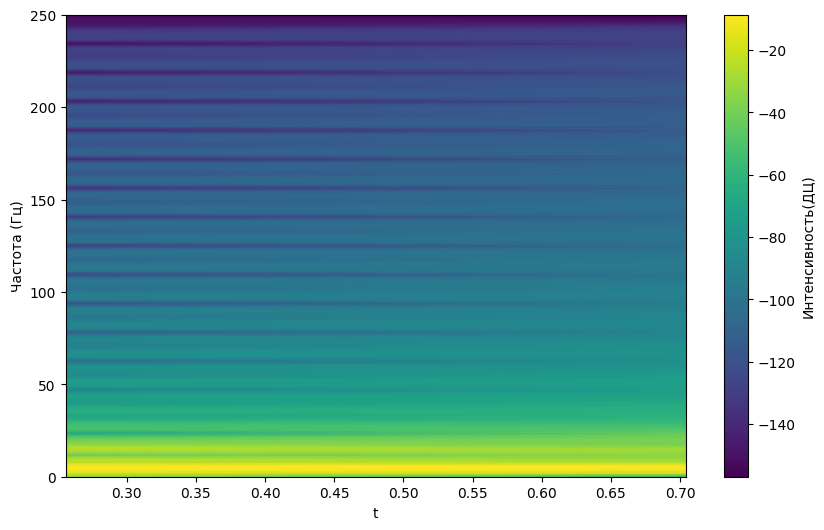

In [15]:
print("Анализ чистого сигнала:")
spectrogramma(signal, fs)
print("Анализ белого шума:")
spectrogramma(noise_signal, fs)
print("Анализ отфильтрованного сигнала:")
spectrogramma(filtered_signal, fs)

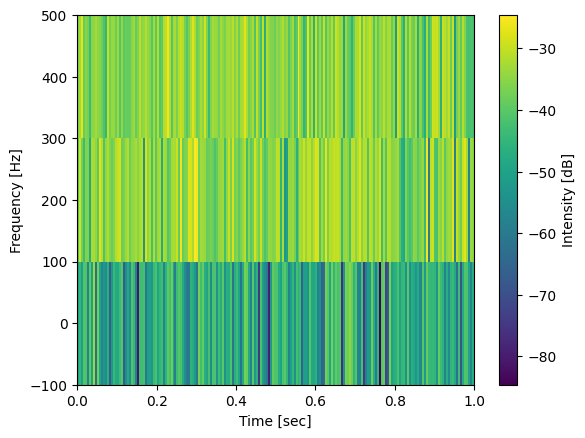

In [ ]:
# Пример

# Блок №2. Повышенный уровень

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from scipy.io import wavfile

## **Задание 1: Чтение и визуализация звукового файла**











В этом задании вам нужно использовать функцию `wavfile.read` из модуля `scipy.io` для чтения звукового файла. Эта функция возвращает частоту дискретизации и данные аудиосигнала. Затем вы должны визуализировать эти данные с помощью `matplotlib.pyplot.plot`. В результате вы получите график амплитуды звукового сигнала во времени.

1. Используйте библиотеку `scipy.io.wavfile` для чтения звукового файла.

In [21]:
sek, data = wavfile.read("Clap 2.wav")
if len(data.shape) > 1:
    data = data[:, 0]

2. Визуализируйте временную форму звукового сигнала.

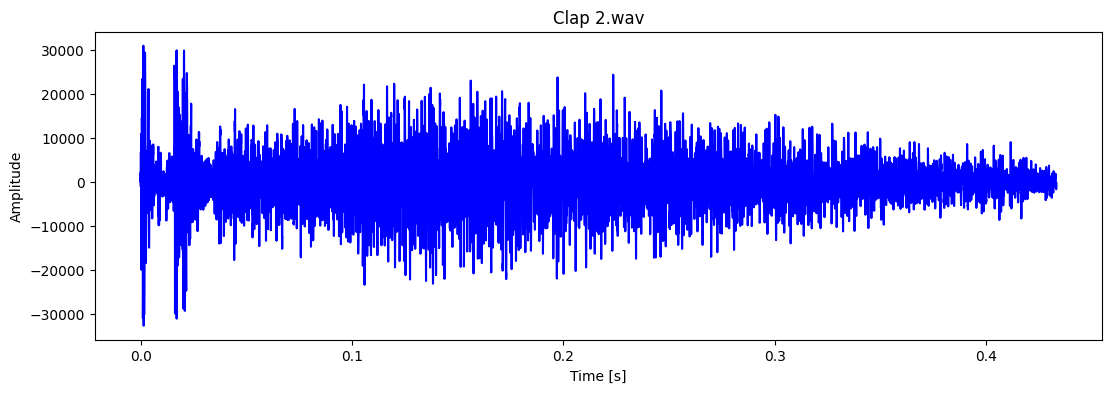

In [26]:
t = np.arange(len(data)) / sek
filename = "Clap 2.wav"
plt.figure(figsize=(13, 4))
plt.plot(t, data, color='blue')
plt.title(filename)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.show()

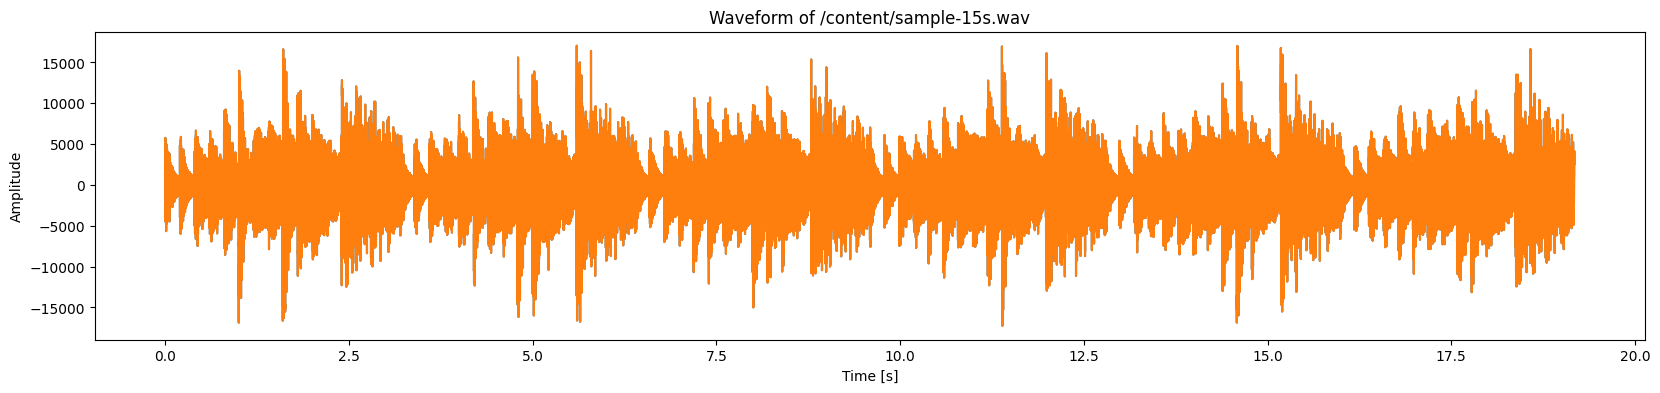

In [ ]:
# Пример

## **Задание 2: Применение преобразования Фурье**



Преобразование Фурье позволяет перейти от временного представления сигнала к частотному. Для его применения вы можете использовать функцию `fft` из модуля `scipy.fft`. Эта функция возвращает комплексные коэффициенты преобразования Фурье, которые затем можно визуализировать.

1. Примените преобразование Фурье к звуковому сигналу и визуализируйте спектр.

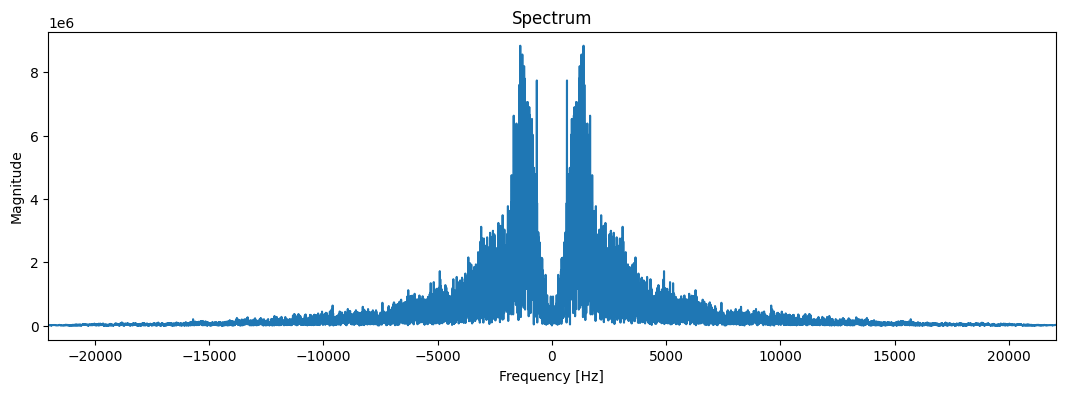

In [27]:
n = len(data)
yf = fft(data)
xf = fftfreq(n, 1/sek)
idx = np.argsort(xf)
xf_sorted = xf[idx]
yf_sorted = np.abs(yf[idx])
plt.figure(figsize=(13, 4))
plt.plot(xf_sorted, yf_sorted)
plt.title('Spectrum')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.xlim(xf_sorted[0], xf_sorted[-1])
plt.show()

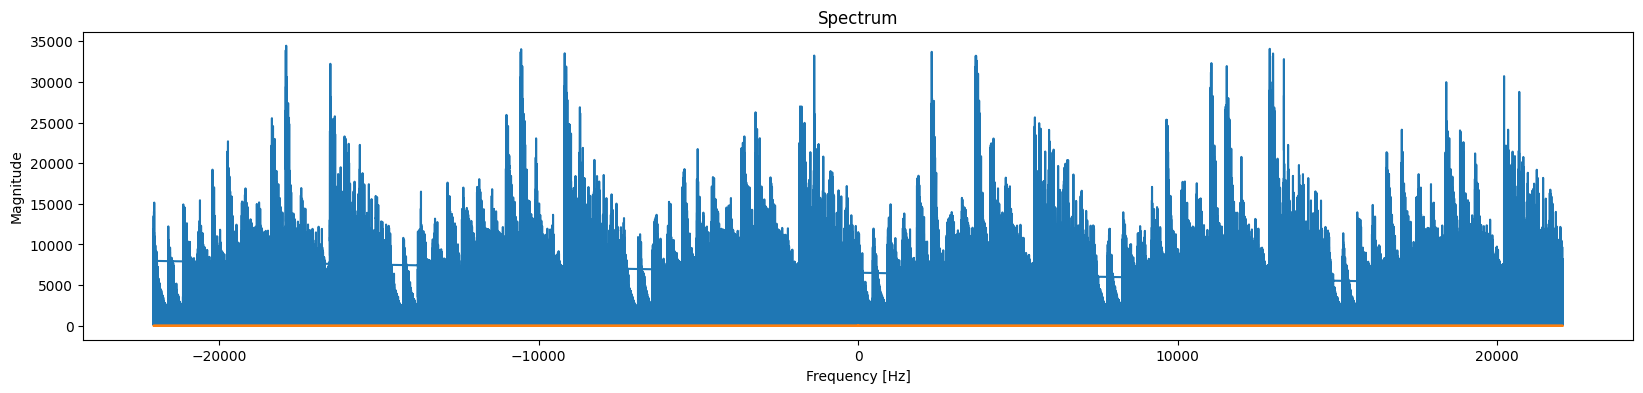

In [ ]:
# Пример

## **Задание 3: Фильтрация сигнала**



Фильтрация сигнала позволяет улучшить качество звука, убрав нежелательные частоты. Для этого вы можете использовать преобразование Фурье, затем обнулить некоторые из его коэффициентов и выполнить обратное преобразование Фурье с помощью функции `ifft` из модуля `scipy.fft`.

1. Создайте функцию для фильтрации сигнала с использованием преобразования Фурье.


In [28]:
def filter_signal_fur(audio_data, cutoff_freq, sampling_sek):
    n = len(audio_data)
    yf = fft(audio_data)
    xf = fftfreq(n, 1/sampling_sek)
    yf_filtered = yf.copy()
    yf_filtered[np.abs(xf) > cutoff_freq] = 0
    filtered_audio = np.real(ifft(yf_filtered))
    return filtered_audio.astype(audio_data.dtype)
cutoff = 3000.0
filtered_data = filter_signal_fur(data, cutoff, sek)


2. Примените эту функцию к звуковому сигналу и визуализируйте результаты до и после фильтрации.

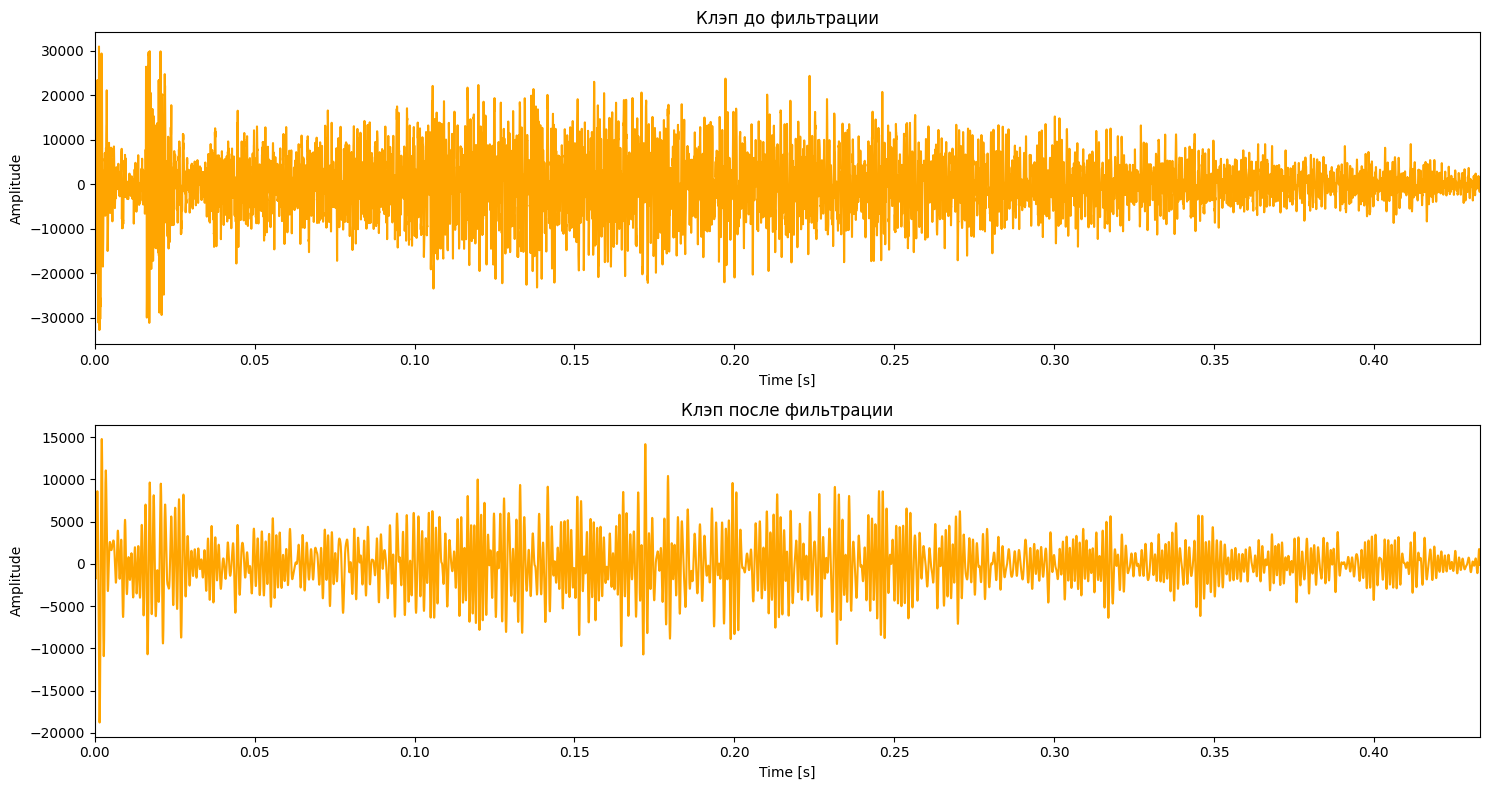

In [30]:
gersz_limit = 1000.0
filtered_data = filter_signal_fur(data, gersz_limit, sek)
t = np.arange(len(data)) / sek
plt.figure(figsize=(15, 8))
plt.subplot(2, 1, 1)
plt.plot(t, data, color='orange')
plt.title('Клэп до фильтрации')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.xlim(0, t[-1])
plt.subplot(2, 1, 2)
plt.plot(t, filtered_data, color='orange')
plt.title(f'Клэп после фильтрации')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.xlim(0, t[-1])
plt.tight_layout()
plt.show()


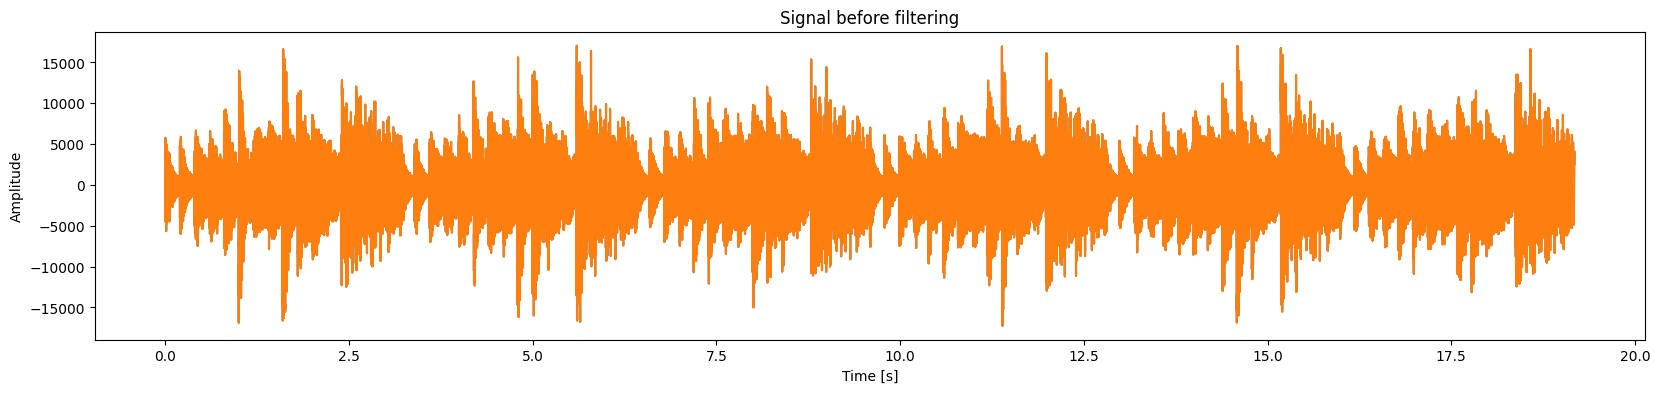

In [ ]:
# Визуализация сигнала до фильтрации

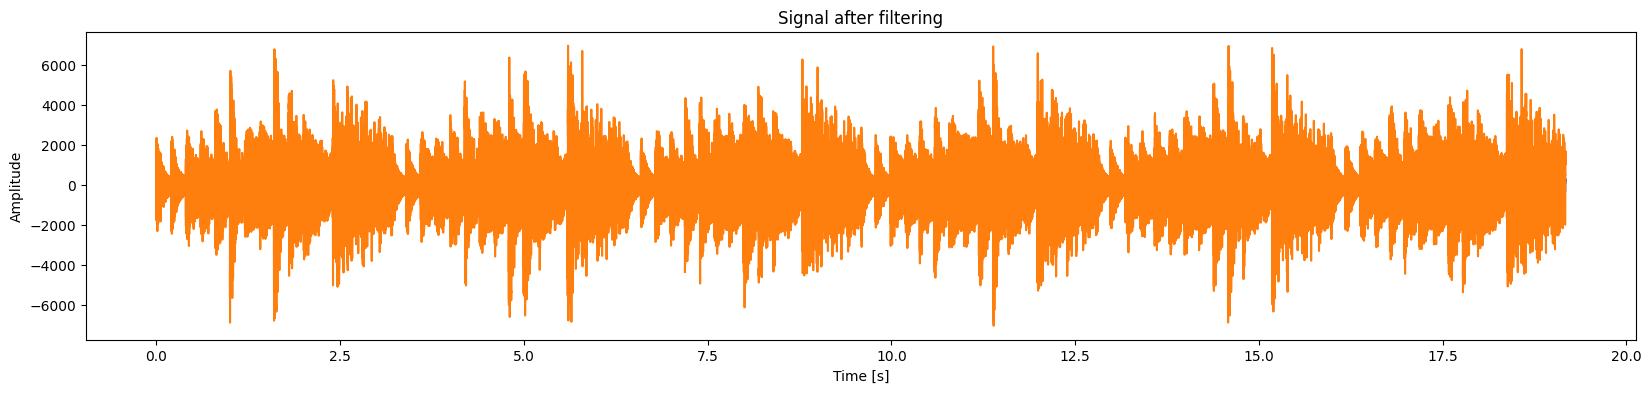

In [ ]:
# Визуализация сигнала после фильтрации

## **Задание 4: Обратное преобразование Фурье**



После фильтрации сигнала вы можете применить обратное преобразование Фурье для получения отфильтрованного звукового сигнала во временной области. Затем вы можете сохранить этот сигнал в новый звуковой файл с помощью функции `wavfile.write` из модуля `scipy.io`.

1. Примените обратное преобразование Фурье к отфильтрованному сигналу.


In [31]:
n = len(data)
yf = fft(data)
xf = fftfreq(n, 1/sek)
gersz_limit = 2000.0
yf_filtered = yf.copy()
yf_filtered[np.abs(xf) > gersz_limit] = 0
recovered_signal = np.real(ifft(yf_filtered))
final_audio = recovered_signal.astype(data.dtype)

2. Сохраните полученный сигнал в новый звуковой файл.

In [32]:
output_filename = "CLAP_FILTERED.wav"
wavfile.write(output_filename, sek, final_audio)